In [1]:
import os

# Set working directory to project root always`n
# Works regardless of where the notebook is saved`n
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [2]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Reload raw data to refit the scaler
df_raw = pd.read_csv(
    'data/telecom/WA_Fn-UseC_-Telco-Customer-Churn.csv'
)
df_raw['TotalCharges'] = pd.to_numeric(
    df_raw['TotalCharges'], errors='coerce'
)
df_raw['TotalCharges'].fillna(0, inplace=True)

# Refit scaler on the same columns
scaler = StandardScaler()
scaler.fit(df_raw[['tenure','MonthlyCharges','TotalCharges']])

print("Scaler ready")
print("Mean  :", scaler.mean_.round(2))
print("Std   :", scaler.scale_.round(2))

Scaler ready
Mean  : [  32.37   64.76 2283.3 ]
Std   : [  24.56   30.09 2266.61]


C:\Users\DELL\AppData\Local\Temp\ipykernel_9432\1519743293.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_raw['TotalCharges'].fillna(0, inplace=True)


In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load preprocessed data
X_train = np.load('outputs/X_train_telecom.npy')
X_test  = np.load('outputs/X_test_telecom.npy')
y_train = np.load('outputs/y_train_telecom.npy')
y_test  = np.load('outputs/y_test_telecom.npy')

feature_names = pd.read_csv(
    'outputs/telecom_feature_names.csv'
).squeeze().tolist()

print("Training shape :", X_train.shape)
print("Test shape     :", X_test.shape)

# Train logistic regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)

print("\nModel trained successfully")

Training shape : (5634, 23)
Test shape     : (1409, 23)

Model trained successfully


In [4]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt

# Predictions
y_pred  = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)[:,1]

# All 5 metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print("="*40)
print("Logistic Regression â€” Telecom")
print("="*40)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print("="*40)
print("\nFull report:")
print(classification_report(y_test, y_pred,
      target_names=['No Churn','Churn']))

Logistic Regression â€” Telecom
Accuracy  : 0.8055
Precision : 0.6582
Recall    : 0.5561
F1 Score  : 0.6029
ROC-AUC   : 0.8421

Full report:
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


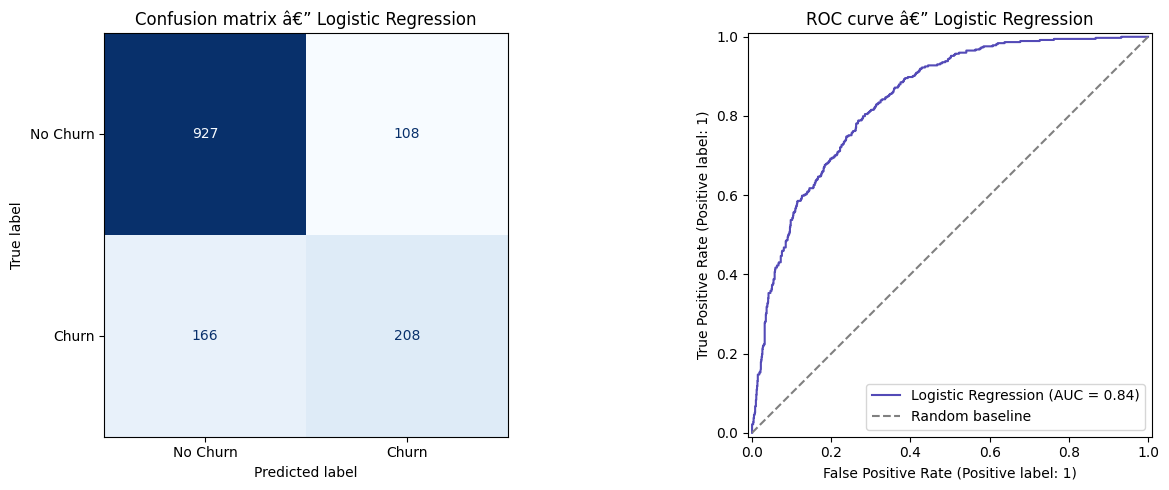

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn','Churn']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix â€” Logistic Regression')

# ROC curve
RocCurveDisplay.from_predictions(
    y_test, y_proba, ax=axes[1],
    name='Logistic Regression',
    color='#534AB7'
)
axes[1].plot([0,1],[0,1],'--',color='gray',
             label='Random baseline')
axes[1].set_title('ROC curve â€” Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.savefig(
    'outputs/plots/telecom/07_lr_evaluation.png',
    bbox_inches='tight'
)
plt.show()

In [6]:
import os

results = {
    'Sector'   : 'Telecom',
    'Model'    : 'Logistic Regression',
    'Accuracy' : round(acc, 4),
    'Precision': round(prec,4),
    'Recall'   : round(rec, 4),
    'F1'       : round(f1,  4),
    'ROC_AUC'  : round(auc, 4)
}

results_df = pd.DataFrame([results])
os.makedirs('outputs/results', exist_ok=True)
results_df.to_csv(
    'outputs/results/telecom_results.csv',
    index=False
)
print(results_df.to_string(index=False))

 Sector               Model  Accuracy  Precision  Recall     F1  ROC_AUC
Telecom Logistic Regression    0.8055     0.6582  0.5561 0.6029   0.8421


In [7]:
import pandas as pd
import numpy as np

# Create one fictional customer
# Column order must match exactly what the model was trained on
new_customer = pd.DataFrame([{
    'gender'              : 1,       # Male
    'SeniorCitizen'       : 0,       # Not senior
    'Partner'             : 0,       # No partner
    'Dependents'          : 0,       # No dependents
    'tenure'              : 2,       # Only 2 months â€” new customer
    'PhoneService'        : 1,
    'MultipleLines'       : 0,
    'OnlineSecurity'      : 0,       # No security
    'OnlineBackup'        : 0,
    'DeviceProtection'    : 0,
    'TechSupport'         : 0,       # No tech support
    'StreamingTV'         : 1,
    'StreamingMovies'     : 1,
    'PaperlessBilling'    : 1,
    'MonthlyCharges'      : 85.0,    # High charges
    'TotalCharges'        : 170.0,   # Low total â€” new customer
}])

# Add the dummy columns for Contract, InternetService, PaymentMethod
# These must match whatever get_dummies created â€” check X_train.columns
new_customer['Contract_One year']         = 0
new_customer['Contract_Two year']         = 0  # Month-to-month (both 0)
new_customer['InternetService_Fiber optic'] = 1
new_customer['InternetService_No']        = 0
new_customer['PaymentMethod_Credit card (automatic)'] = 0
new_customer['PaymentMethod_Electronic check']        = 1
new_customer['PaymentMethod_Mailed check']            = 0

# Scale the numerical columns using the same scaler
new_customer[['tenure','MonthlyCharges','TotalCharges']] = scaler.transform(
    new_customer[['tenure','MonthlyCharges','TotalCharges']]
)

# Predict
prediction = lr_model.predict(new_customer)
probability = lr_model.predict_proba(new_customer)[:,1]

print(f"Prediction  : {'CHURN' if prediction[0]==1 else 'STAY'}")
print(f"Probability : {probability[0]*100:.1f}% chance of churning")

Prediction  : CHURN
Probability : 79.4% chance of churning


c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [8]:
loyal_customer = new_customer.copy()

# Override key values
loyal_customer['tenure']         = 60   # 5 years
loyal_customer['MonthlyCharges'] = 25.0 # Low charges
loyal_customer['TotalCharges']   = 1500.0
loyal_customer['Contract_Two year'] = 1  # Two year contract
loyal_customer['Contract_One year'] = 0

# Re-scale
loyal_customer[['tenure','MonthlyCharges','TotalCharges']] = scaler.transform(
    loyal_customer[['tenure','MonthlyCharges','TotalCharges']]
)

pred2 = lr_model.predict(loyal_customer)
prob2 = lr_model.predict_proba(loyal_customer)[:,1]

print(f"Prediction  : {'CHURN' if pred2[0]==1 else 'STAY'}")
print(f"Probability : {prob2[0]*100:.1f}% chance of churning")

Prediction  : STAY
Probability : 11.9% chance of churning


c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
